In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make sure project root is on path so we can import src.*
import sys
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.dataset import assemble_dataset
from src.features import build_supervised_dataset
from src.train import train_per_horizon_models, temporal_split

# Load processed historical data
DATA_DIR = project_root / "data" / "processed"

dam = pd.read_csv(DATA_DIR / "dam_prices_historical_hourly.csv", index_col=0, parse_dates=True)
load = pd.read_csv(DATA_DIR / "forecast_historical_hourly.csv", index_col=0, parse_dates=True)
renewable = pd.read_csv(DATA_DIR / "renewable_forecast_historical_hourly.csv", index_col=0, parse_dates=True)

# Pandas reads tz-aware timestamps as UTC by default; ensure tz
for df in (dam, load, renewable):
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    else:
        df.index = df.index.tz_convert("UTC")

prices, exog = assemble_dataset(dam, load, renewable, join="inner")
print(f"Data: {len(prices)} rows")
print(f"Range: {prices.index.min()}  →  {prices.index.max()}")

Data: 29352 rows
Range: 2022-12-31 22:00:00+00:00  →  2026-05-07 21:00:00+00:00


In [3]:
def naive_yesterday_baseline(prices, forecast_time, horizon):
    """Predict tomorrow's hour H = today's hour H (which equals 'yesterday' relative to target)."""
    target_time = forecast_time + pd.Timedelta(hours=(24 - forecast_time.hour) + horizon)
    return prices.get(target_time - pd.Timedelta(days=1), np.nan)


def naive_last_week_baseline(prices, forecast_time, horizon):
    """Predict tomorrow's hour H = same hour 7 days ago."""
    target_time = forecast_time + pd.Timedelta(hours=(24 - forecast_time.hour) + horizon)
    return prices.get(target_time - pd.Timedelta(days=7), np.nan)


def naive_average_yest_lastweek(prices, forecast_time, horizon):
    """Predict tomorrow's hour H = average of (1d ago, 7d ago)."""
    a = naive_yesterday_baseline(prices, forecast_time, horizon)
    b = naive_last_week_baseline(prices, forecast_time, horizon)
    if np.isnan(a) or np.isnan(b):
        return a if not np.isnan(a) else b
    return (a + b) / 2


# Pick a test window matching what we'll use for the model: last 30 days
gate_closure_hour = 12
forecast_times = pd.date_range(
    start=prices.index.max() - pd.Timedelta(days=35),  # a bit more for buffer
    end=prices.index.max() - pd.Timedelta(days=2),  # need at least 1 day of target
    freq="D",
    tz="UTC",
).map(lambda d: d.normalize() + pd.Timedelta(hours=gate_closure_hour - 3))  # 12:00 Athens = 09:00 UTC (summer)

# Build baseline predictions for each (forecast_time, horizon)
baselines = {"naive_d1": [], "naive_d7": [], "naive_avg": []}
actuals = []
ft_horizon_pairs = []

for ft in forecast_times:
    for h in range(24):
        target_time = ft + pd.Timedelta(hours=(24 - ft.hour) + h)
        if target_time not in prices.index or pd.isna(prices[target_time]):
            continue
        actuals.append(prices[target_time])
        baselines["naive_d1"].append(naive_yesterday_baseline(prices, ft, h))
        baselines["naive_d7"].append(naive_last_week_baseline(prices, ft, h))
        baselines["naive_avg"].append(naive_average_yest_lastweek(prices, ft, h))
        ft_horizon_pairs.append((ft, h))

actuals = np.array(actuals)
print(f"Test set: {len(actuals)} (forecast_time, horizon) pairs")

# Compute MAE for each baseline
for name, preds in baselines.items():
    preds = np.array(preds)
    valid = ~(np.isnan(preds) | np.isnan(actuals))
    mae = np.abs(preds[valid] - actuals[valid]).mean()
    rmse = np.sqrt(((preds[valid] - actuals[valid]) ** 2).mean())
    print(f"  {name:15s}: MAE={mae:6.2f}  RMSE={rmse:6.2f}  (n={valid.sum()})")

Test set: 816 (forecast_time, horizon) pairs
  naive_d1       : MAE= 21.40  RMSE= 33.54  (n=816)
  naive_d7       : MAE= 28.34  RMSE= 44.01  (n=816)
  naive_avg      : MAE= 20.93  RMSE= 30.64  (n=816)


In [5]:
result_new = train_per_horizon_models(
    prices, exog=exog,
    gate_closure_hour=12,
    horizons=tuple(range(24)),
    same_hour_lag_days=(1, 2, 7),
    context_window=1,
    test_days=30,
    lgbm_params={
        "n_estimators": 300,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 20,
        "random_state": 42,
        "verbose": -1,
    },
)

print(result_new.summary())
print()
print("Per-horizon MAE (NEW features):")
print(result_new.metrics_per_horizon[["horizon", "mae", "rmse"]].to_string(index=False))

TrainResult Summary
  Models trained:    24 per-horizon LightGBM models
  Features:          38
  Gate closure:      12:00
  Overall test MAE:  17.37 EUR/MWh
  Overall test RMSE: 22.84 EUR/MWh
  Best horizon:      h=20 (MAE 11.67)
  Worst horizon:     h=18 (MAE 26.85)

Per-horizon MAE (NEW features):
 horizon       mae      rmse
       0 15.915661 18.477494
       1 16.091344 19.793032
       2 13.597451 17.257114
       3 12.153980 15.171699
       4 14.424108 19.715019
       5 16.621318 21.085534
       6 19.832098 26.224585
       7 17.914815 22.582020
       8 12.998939 18.878811
       9 15.245669 27.003855
      10 16.403640 26.482028
      11 13.881703 24.815761
      12 20.390986 26.013260
      13 20.649905 28.234143
      14 26.686158 35.418895
      15 24.463837 28.694805
      16 14.473950 18.535893
      17 23.152059 28.567226
      18 26.846801 33.268603
      19 17.822528 21.865036
      20 11.666457 14.179734
      21 14.275006 17.799581
      22 15.143068 19.038808
  

In [6]:
# Build the feature matrix the new way
X, y, meta = build_supervised_dataset(
    prices, exog=exog,
    gate_closure_hour=12,
    horizons=tuple(range(24)),
    same_hour_lag_days=(1, 2, 7),
    context_window=1,
)

# Now mask out features that the OLD leakage check would have NaN'd
tr_cols = [c for c in X.columns if c.startswith("tr_lag_")]
X_old = X.copy()

for col in tr_cols:
    after_d = col[len("tr_lag_d"):]
    d_str, k_str = after_d.split("_k")
    d, k = int(d_str), int(k_str)
    offset_hours = 24 * d - k

    # For each row, the OLD code NaN'd this column if offset_hours < distance
    # where distance = (24 - gate_closure_hour) + horizon
    for h in range(24):
        distance = (24 - 12) + h
        if offset_hours < distance:
            h_mask = (meta["horizon"] == h).values
            X_old.loc[h_mask, col] = np.nan

# Train the same way, but on X_old
# We can't reuse train_per_horizon_models directly because it would rebuild features.
# So we manually do the split + per-horizon training.

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

X_tr, y_tr, m_tr, X_te, y_te, m_te = temporal_split(X_old, y, meta, test_days=30)

models_old = {}
metrics_old = []
lgbm_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_child_samples": 20,
    "random_state": 42,
    "verbose": -1,
}

for h in range(24):
    train_mask = m_tr["horizon"] == h
    test_mask = m_te["horizon"] == h
    if not train_mask.any() or not test_mask.any():
        continue
    
    X_tr_h = X_tr[train_mask].drop(columns=["horizon"])
    y_tr_h = y_tr[train_mask]
    X_te_h = X_te[test_mask].drop(columns=["horizon"])
    y_te_h = y_te[test_mask]
    
    model = lgb.LGBMRegressor(**lgbm_params)
    model.fit(X_tr_h, y_tr_h)
    models_old[h] = model
    
    pred = model.predict(X_te_h)
    metrics_old.append({
        "horizon": h,
        "mae": mean_absolute_error(y_te_h, pred),
        "rmse": np.sqrt(mean_squared_error(y_te_h, pred)),
        "n_test": len(y_te_h),
    })

metrics_old_df = pd.DataFrame(metrics_old)
weights = metrics_old_df["n_test"].to_numpy()
overall_mae_old = float(np.average(metrics_old_df["mae"], weights=weights))
overall_rmse_old = float(np.average(metrics_old_df["rmse"], weights=weights))

print(f"OLD features: Overall test MAE: {overall_mae_old:.2f}  RMSE: {overall_rmse_old:.2f}")
print()
print("Per-horizon MAE (OLD features):")
print(metrics_old_df[["horizon", "mae", "rmse"]].to_string(index=False))

OLD features: Overall test MAE: 17.47  RMSE: 22.79

Per-horizon MAE (OLD features):
 horizon       mae      rmse
       0 15.915661 18.477494
       1 16.091344 19.793032
       2 13.597451 17.257114
       3 12.153980 15.171699
       4 14.424108 19.715019
       5 16.621318 21.085534
       6 19.832098 26.224585
       7 17.914815 22.582020
       8 12.998939 18.878811
       9 15.245669 27.003855
      10 16.403640 26.482028
      11 13.881703 24.815761
      12 20.692472 26.667162
      13 20.047539 26.613188
      14 27.470309 35.950456
      15 23.483855 27.447124
      16 17.446851 21.794651
      17 23.408404 27.971618
      18 24.251540 29.509754
      19 17.104658 22.183825
      20 13.283984 15.592121
      21 15.151139 18.519455
      22 15.536929 18.245140
      23 16.227247 18.733168


In [7]:
# Build a unified comparison table
comparison = result_new.metrics_per_horizon[["horizon", "mae"]].rename(
    columns={"mae": "new_features_mae"}
).merge(
    metrics_old_df[["horizon", "mae"]].rename(columns={"mae": "old_features_mae"}),
    on="horizon",
)

# Add naive baselines per horizon
naive_mae_by_h = {}
for name, preds in baselines.items():
    preds = np.array(preds)
    horizons_arr = np.array([h for _, h in ft_horizon_pairs])
    valid_global = ~(np.isnan(preds) | np.isnan(actuals))
    naive_mae_by_h[name] = []
    for h in range(24):
        mask = (horizons_arr == h) & valid_global
        if mask.sum() == 0:
            naive_mae_by_h[name].append(np.nan)
            continue
        naive_mae_by_h[name].append(np.abs(preds[mask] - actuals[mask]).mean())

for name in ["naive_d1", "naive_d7", "naive_avg"]:
    comparison[name + "_mae"] = naive_mae_by_h[name]

comparison["improvement_vs_old"] = comparison["old_features_mae"] - comparison["new_features_mae"]

print("Per-horizon MAE comparison:")
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
print()
print("=" * 60)
print(f"Overall MAE (weighted by n_test):")
print(f"  Naive (yesterday):      {np.abs(np.array(baselines['naive_d1']) - actuals)[~(np.isnan(np.array(baselines['naive_d1'])) | np.isnan(actuals))].mean():6.2f}")
print(f"  Naive (last week):      {np.abs(np.array(baselines['naive_d7']) - actuals)[~(np.isnan(np.array(baselines['naive_d7'])) | np.isnan(actuals))].mean():6.2f}")
print(f"  Naive (avg):            {np.abs(np.array(baselines['naive_avg']) - actuals)[~(np.isnan(np.array(baselines['naive_avg'])) | np.isnan(actuals))].mean():6.2f}")
print(f"  Old features (model):   {overall_mae_old:6.2f}")
print(f"  New features (model):   {result_new.overall_test_mae:6.2f}")
print("=" * 60)
print(f"Improvement of new vs old: {overall_mae_old - result_new.overall_test_mae:+.2f} EUR/MWh")
print(f"Improvement of model vs naive_avg: {np.abs(np.array(baselines['naive_avg']) - actuals)[~(np.isnan(np.array(baselines['naive_avg'])) | np.isnan(actuals))].mean() - result_new.overall_test_mae:+.2f} EUR/MWh")

Per-horizon MAE comparison:
 horizon  new_features_mae  old_features_mae  naive_d1_mae  naive_d7_mae  naive_avg_mae  improvement_vs_old
       0             15.92             15.92         12.55         14.54          11.97                0.00
       1             16.09             16.09         13.57         15.47          13.24                0.00
       2             13.60             13.60         14.84         17.71          14.69                0.00
       3             12.15             12.15         13.64         13.52          12.41                0.00
       4             14.42             14.42         23.92         16.62          16.64                0.00
       5             16.62             16.62         34.28         34.56          27.85                0.00
       6             19.83             19.83         37.83         52.41          36.16                0.00
       7             17.91             17.91         25.39         39.68          28.01                0.00


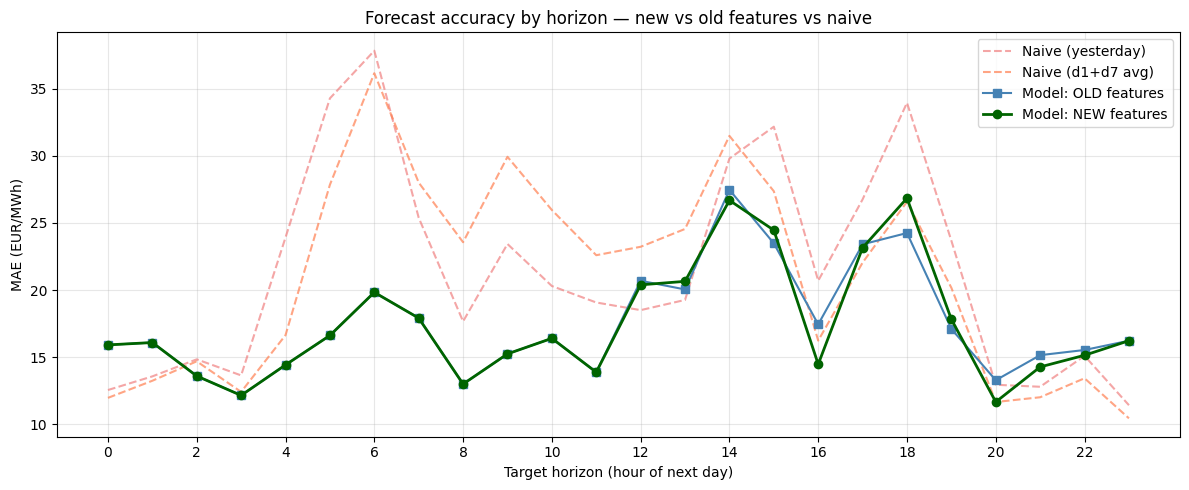

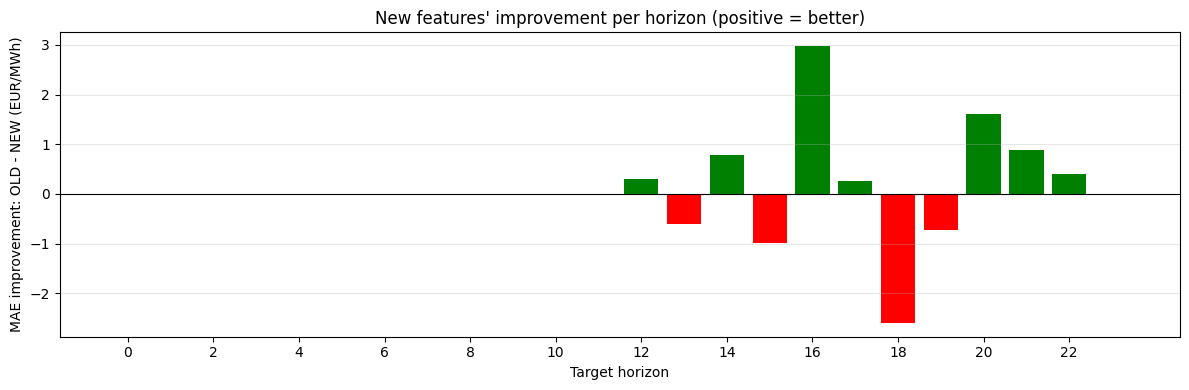

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(comparison["horizon"], comparison["naive_d1_mae"], 
        label="Naive (yesterday)", color="lightcoral", linestyle="--", alpha=0.7)
ax.plot(comparison["horizon"], comparison["naive_avg_mae"],
        label="Naive (d1+d7 avg)", color="coral", linestyle="--", alpha=0.7)
ax.plot(comparison["horizon"], comparison["old_features_mae"],
        label="Model: OLD features", color="steelblue", marker="s")
ax.plot(comparison["horizon"], comparison["new_features_mae"],
        label="Model: NEW features", color="darkgreen", marker="o", linewidth=2)

ax.set_xlabel("Target horizon (hour of next day)")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_title("Forecast accuracy by horizon — new vs old features vs naive")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

# A second plot: improvement (old - new) per horizon
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(comparison["horizon"], comparison["improvement_vs_old"],
       color=["green" if v >= 0 else "red" for v in comparison["improvement_vs_old"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Target horizon")
ax.set_ylabel("MAE improvement: OLD - NEW (EUR/MWh)")
ax.set_title("New features' improvement per horizon (positive = better)")
ax.grid(True, alpha=0.3, axis="y")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

In [9]:
# Pick a horizon that benefits most from new features (typically evening hours)
peak_h = 20

model = result_new.models[peak_h]
fi = pd.DataFrame({
    "feature": result_new.feature_names,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

print(f"Top 15 features for horizon {peak_h}:")
print(fi.head(15).to_string(index=False))

# Specifically: did `tr_lag_d1_k+0` make the top features?
# This was always NaN under the old code for h>=13, so the model only sees real values now.
tr_d1 = fi[fi["feature"].str.startswith("tr_lag_d1")]
print(f"\nrank of tr_lag_d1_* features for horizon {peak_h}:")
for _, row in tr_d1.iterrows():
    rank = fi.index.get_loc(row.name) + 1
    print(f"  {row['feature']:25s}  importance={row['importance']:6.0f}  rank={rank}")

Top 15 features for horizon 20:
                feature  importance
     target_net_load_mw         572
          tr_lag_d1_k+0         481
    target_wind_onshore         438
          tr_lag_d1_k-1         429
        ft_wind_onshore         408
          tr_lag_d7_k+0         391
          tr_lag_d7_k-1         380
            ft_std_168h         380
target_load_forecast_mw         370
    ft_load_forecast_mw         366
          tr_lag_d2_k+1         346
           ft_mean_168h         336
          tr_lag_d2_k+0         334
            ft_mean_24h         303
          tr_lag_d2_k-1         293

rank of tr_lag_d1_* features for horizon 20:
  tr_lag_d1_k+0              importance=   481  rank=2
  tr_lag_d1_k-1              importance=   429  rank=4
  tr_lag_d1_k+1              importance=   234  rank=21


Forecast for: 2026-05-07 00:00:00+00:00  (made at 2026-05-06 12:00:00+00:00)


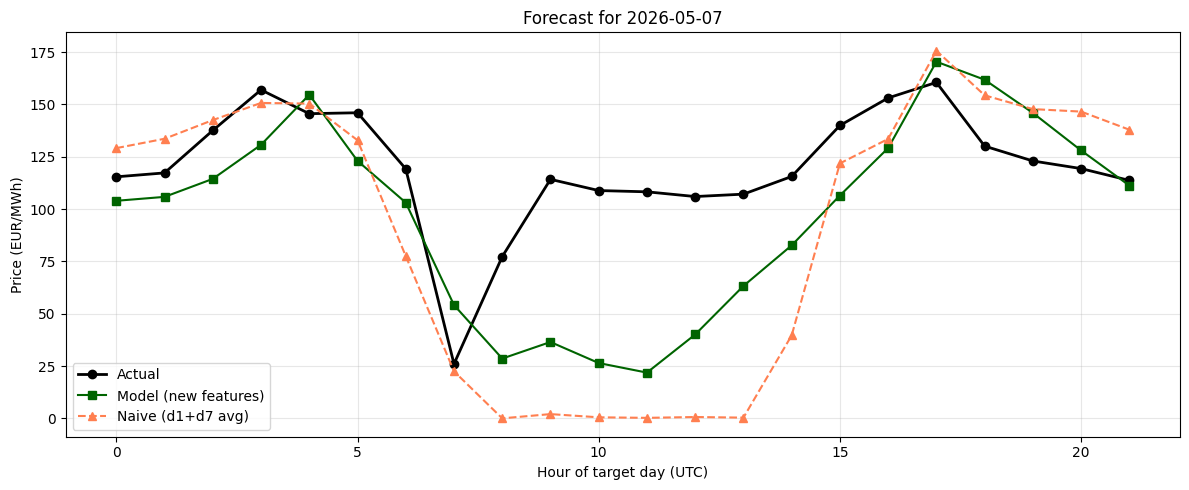

Model MAE for this day: 32.71
Naive MAE for this day: 43.25


In [10]:
# Pick the most recent forecast day in the test set
last_ft = result_new.meta_test["forecast_time"].max()
print(f"Forecast for: {last_ft + pd.Timedelta(hours=12)}  (made at {last_ft})")

# Pred + actual for this forecast_time
mask = result_new.meta_test["forecast_time"] == last_ft
test_h = result_new.meta_test[mask]["horizon"].values
test_y = result_new.y_test[mask].values

# Re-compute predictions for this forecast_time
preds_for_day = []
for _, row in result_new.meta_test[mask].iterrows():
    h = row["horizon"]
    X_te = result_new.X_test
    row_idx = row.name
    X_row = X_te.loc[[row_idx]].drop(columns=["horizon"])
    pred = result_new.models[h].predict(X_row)[0]
    preds_for_day.append(pred)

# Compare to naive baseline for the same day
naive_for_day = []
for _, row in result_new.meta_test[mask].iterrows():
    naive_for_day.append(naive_average_yest_lastweek(prices, last_ft, row["horizon"]))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_h, test_y, label="Actual", marker="o", color="black", linewidth=2)
ax.plot(test_h, preds_for_day, label="Model (new features)", marker="s", color="darkgreen")
ax.plot(test_h, naive_for_day, label="Naive (d1+d7 avg)", marker="^", color="coral", linestyle="--")
ax.set_xlabel("Hour of target day (UTC)")
ax.set_ylabel("Price (EUR/MWh)")
ax.set_title(f"Forecast for {(last_ft + pd.Timedelta(hours=12)).date()}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# MAE for this day
day_mae = np.abs(np.array(preds_for_day) - test_y).mean()
naive_mae = np.nanmean(np.abs(np.array(naive_for_day) - test_y))
print(f"Model MAE for this day: {day_mae:.2f}")
print(f"Naive MAE for this day: {naive_mae:.2f}")

In [11]:
prices

2022-12-31 22:00:00+00:00    210.0500
2022-12-31 23:00:00+00:00    230.9000
2023-01-01 00:00:00+00:00    268.1900
2023-01-01 01:00:00+00:00    229.5800
2023-01-01 02:00:00+00:00    235.9800
                               ...   
2026-05-07 17:00:00+00:00    160.5125
2026-05-07 18:00:00+00:00    130.0750
2026-05-07 19:00:00+00:00    122.9725
2026-05-07 20:00:00+00:00    119.3350
2026-05-07 21:00:00+00:00    113.6850
Freq: h, Name: price_eur_mwh, Length: 29352, dtype: float64